In [18]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Dropout
from imblearn.over_sampling import SMOTE
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

In [19]:
df = pd.read_csv("C:/Users/maman/OneDrive/שולחן העבודה/dataset-stroke-cleaned1.csv")

In [20]:
# Converting to boolean 
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})
df["Residence_type"] = df["Residence_type"].map({"Rural": 1, "Urban": 0})

In [21]:
# Combine features
X = df.drop('stroke', axis=1)
y = df['stroke']

In [22]:
# Split the data into training, validation and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# Division into types of variables
cat_cols = ['gender', 'work_type', 'smoking_status']
bin_cols = ['hypertension', 'heart_disease', 'Residence_type','ever_married']
num_cols = ['age', 'avg_glucose_level', 'bmi']

In [24]:
# Encode categorical features
ohe = OneHotEncoder(drop=None, sparse_output=False);
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat  = ohe.transform(X_test[cat_cols])

In [25]:
# Turn binary features into NumPy array for easy concatenation with other feature arrays
X_train_bin = X_train[bin_cols].to_numpy()
X_test_bin = X_test[bin_cols].to_numpy()

In [26]:
# Scale features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num  = scaler.transform(X_test[num_cols])

In [39]:
# Combine
X_train_ready = np.hstack([X_train_cat, X_train_bin, X_train_num])
X_test_ready  = np.hstack([X_test_cat, X_test_bin, X_test_num])

In [40]:
# Early stopping to prevent overfitting, stops training if validation loss doesn’t improve for 5 epochs.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=1e-4
)

In [41]:
# Build neural network
model = tf.keras.Sequential([
     tf.keras.layers.Input(shape=(X_train_ready.shape[1],)),
    tf.keras.layers.Dense(320, activation='relu'),
    Dropout(0.15),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [42]:
# Train the model on the training set with validation
history = model.fit(
    X_train_ready, y_train,
    epochs=30, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9453 - loss: 0.3240 - val_accuracy: 0.9580 - val_loss: 0.1430
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9533 - loss: 0.1588 - val_accuracy: 0.9580 - val_loss: 0.1324
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9602 - loss: 0.1356 - val_accuracy: 0.9580 - val_loss: 0.1320
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9607 - loss: 0.1270 - val_accuracy: 0.9580 - val_loss: 0.1318
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9619 - loss: 0.1252 - val_accuracy: 0.9580 - val_loss: 0.1332
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9607 - loss: 0.1292 - val_accuracy: 0.9580 - val_loss: 0.1316
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9542 - loss: 0.1347 - val_accuracy: 0.9580 - val_loss: 0.1365
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9612 - loss: 0.1233 - val_accuracy: 0.9593 - val_loss:

In [43]:
# Evaluate the trained model on the test dataset and display accuracy
loss, accuracy = model.evaluate(X_test_ready, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.96


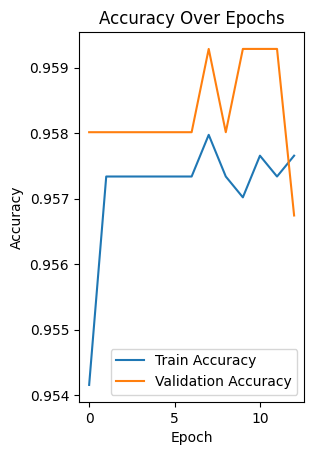

In [44]:
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

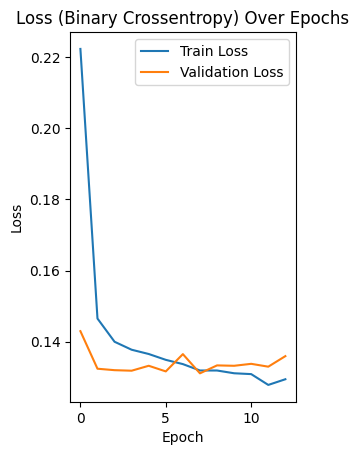

In [45]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss (Binary Crossentropy) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
y_pred = (model.predict(X_test_ready, verbose=0) >= 0.5).astype(int)
# דוח סיווג
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3, zero_division=0))
# מטריצת בלבול
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# ROC AUC
y_proba = model.predict(X_test_ready, verbose=0).ravel()
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0      0.957     0.999     0.978       940
           1      0.000     0.000     0.000        42

    accuracy                          0.956       982
   macro avg      0.479     0.499     0.489       982
weighted avg      0.916     0.956     0.936       982

Confusion Matrix:
 [[939   1]
 [ 42   0]]
ROC AUC Score: 0.7949594731509625
